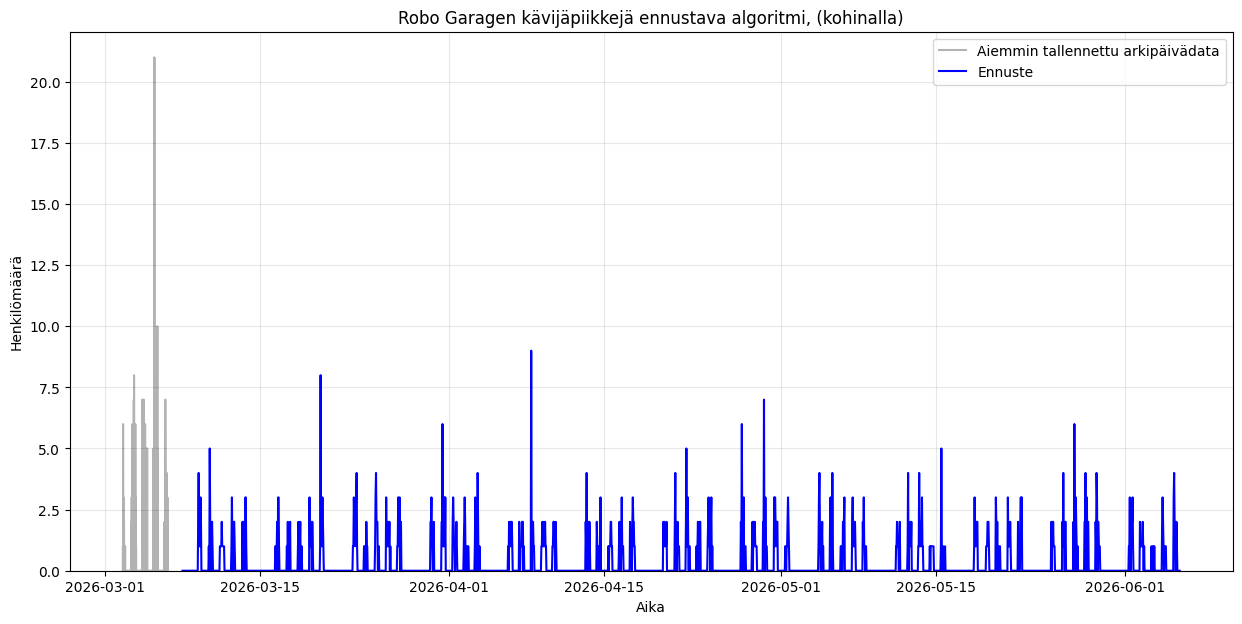

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ladataan Robo Garagen data
df = pd.read_json('/content/robo.data.json')
payload_df = pd.json_normalize(df['payload'])
df = pd.concat([df.drop(columns=['payload']), payload_df], axis=1)

df['TimeStamp'] = pd.to_datetime(df['TimeStamp'], format='%d.%m.%Y klo %H.%M.%S', errors='coerce')
df = df.dropna(subset=['TimeStamp'])
df = df.sort_values(by='TimeStamp')

start_train = pd.to_datetime('2026-03-02 00:00:00')
end_train = pd.to_datetime('2026-03-07 23:59:59')
train_data_full = df[(df['TimeStamp'] >= start_train) & (df['TimeStamp'] <= end_train)].copy()

train_data_full['hour'] = train_data_full['TimeStamp'].dt.hour
train_data_full['day_of_week'] = train_data_full['TimeStamp'].dt.dayofweek

school_hours_data = train_data_full[
    (train_data_full['day_of_week'] <= 4) &
    (train_data_full['hour'] >= 8) &
    (train_data_full['hour'] <= 19)
]

# Lasketaan keskiarvo per tunti arkipäiviltä aiemmin tallennetun datan perusteella
hourly_profile = school_hours_data.groupby('hour')['person count'].mean().reindex(range(8, 20), fill_value=0)

# Lasketaan aiemmin tallennetun datan keskihajonta tunneittain realistisen vaihtelun lisäämiseksi
hourly_std = school_hours_data.groupby('hour')['person count'].std().reindex(range(8, 20), fill_value=0)

# Täytetään keskihajonnat nollalla, jos tunnilla oli vain yksi datapiste (keskihajonta olisi NaN)
hourly_std = hourly_std.fillna(0)


# 3. Luodaan ennuste 3 kuukaudelle
future_dates = pd.date_range(start='2026-03-08', periods=90*24, freq='h')
forecast_df = pd.DataFrame({'TimeStamp': future_dates})
forecast_df['hour'] = forecast_df['TimeStamp'].dt.hour
forecast_df['day_of_week'] = forecast_df['TimeStamp'].dt.dayofweek

def get_historical_prediction(row):
    if row['day_of_week'] <= 4 and 8 <= row['hour'] <= 19:
        return hourly_profile.get(row['hour'], 0)
    return 0

forecast_df['predicted_count_base'] = forecast_df.apply(get_historical_prediction, axis=1)

# Kohinan lisäys
def add_realistic_noise(row):
    if row['day_of_week'] <= 4 and 8 <= row['hour'] <= 19:
        std_dev = hourly_std.get(row['hour'], 0)
        noise = np.random.normal(0, std_dev * 0.5)
        return max(0, round(row['predicted_count_base'] + noise))
    return round(row['predicted_count_base'])

forecast_df['predicted_count_realistic'] = forecast_df.apply(add_realistic_noise, axis=1)


# 4. Visualisointi
plt.figure(figsize=(15, 7))
sns.lineplot(x='TimeStamp', y='person count', data=school_hours_data, label='Aiemmin tallennettu arkipäivädata', color='black', alpha=0.3)
sns.lineplot(x='TimeStamp', y='predicted_count_realistic', data=forecast_df, label='Ennuste', color='blue')

plt.title('Robo Garagen kävijäpiikkejä ennustava algoritmi, (kohinalla)')
plt.xlabel('Aika')
plt.ylabel('Henkilömäärä')
plt.ylim(bottom=0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [16]:
import os

file_path = '/content/robo.data.json'
if os.path.exists(file_path):
    print(f"Tiedosto '{file_path}' löytyi.")
else:
    print(f"Tiedostoa '{file_path}' ei löytynyt. Varmista, että olet ladannut sen.")

Tiedosto '/content/robo.data.json' löytyi.


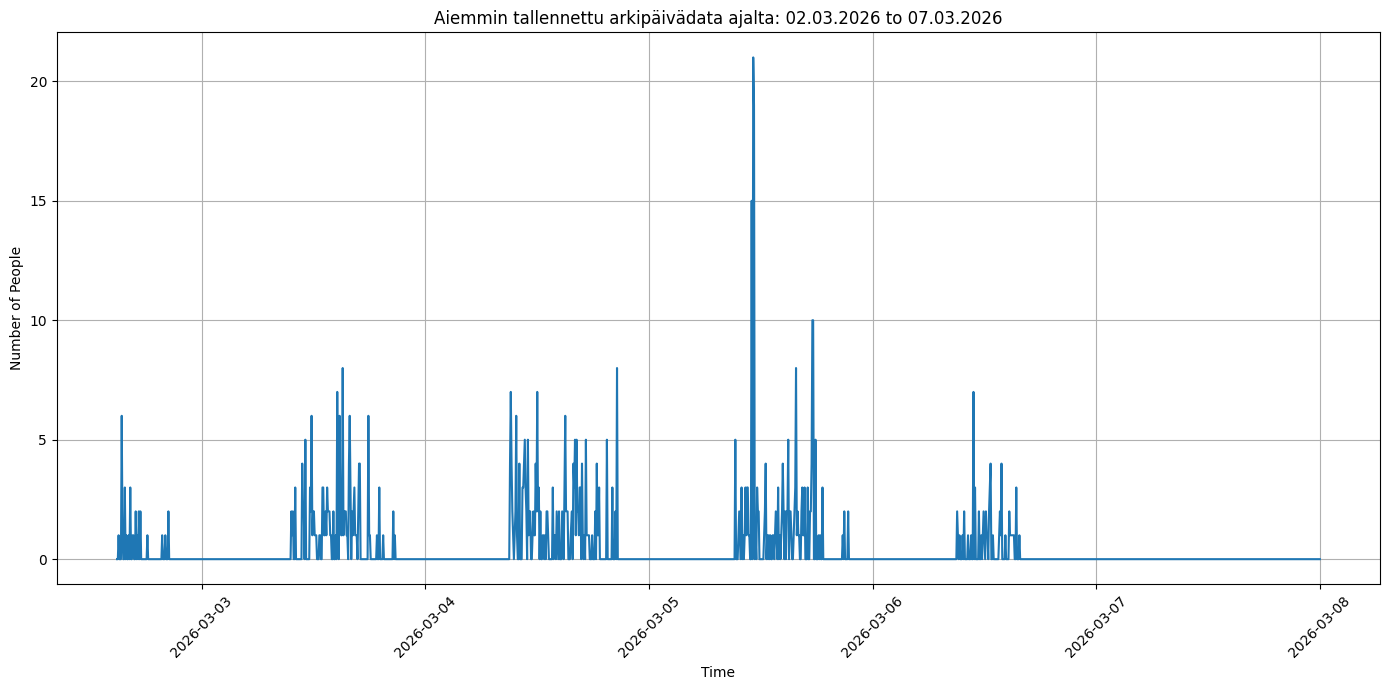

In [17]:
# Määritellään suodatuksen aloitus- ja lopetuspäivämäärät
start_date = pd.to_datetime('02.03.2026 klo 00.00.00', format='%d.%m.%Y klo %H.%M.%S')
end_date = pd.to_datetime('07.03.2026 klo 23.59.59', format='%d.%m.%Y klo %H.%M.%S')

# Varmistetaan, että 'TimeStamp'-sarake on datetime-muodossa ennen suodatusta
df['TimeStamp'] = pd.to_datetime(df['TimeStamp'], format='%d.%m.%Y klo %H.%M.%S', errors='coerce')
# Pudotetaan rivit, joissa TimeStamp-muunnos epäonnistui (NaT), jotta vältetään ongelmat suodatuksessa
df_processed = df.dropna(subset=['TimeStamp'])

# Suodatetaan DataFrame määritellylle päivämääräalueelle
df_filtered = df_processed[(df_processed['TimeStamp'] >= start_date) & (df_processed['TimeStamp'] <= end_date)]

# Luodaan viivakaavio suodatetulle datalle
plt.figure(figsize=(14, 7))
sns.lineplot(x='TimeStamp', y='person count', data=df_filtered)
plt.title(f'Aiemmin tallennettu arkipäivädata ajalta: {start_date.strftime('%d.%m.%Y')} to {end_date.strftime('%d.%m.%Y')}')
plt.xlabel('Time')
plt.ylabel('Number of People')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
print("Ennusteen perustana käytetty tuntikohtainen profiili (aiemmin tallennetun datan arkipäivien keskiarvot):")
display(hourly_profile.to_frame(name='Keskimääräinen henkilömäärä'))

Ennusteen perustana käytetty tuntikohtainen profiili (aiemmin tallennetun datan arkipäivien keskiarvot):


,Keskimääräinen henkilömäärä
hour,
8,0.000000
9,1.106383
10,1.270833
11,2.291667
12,1.041667
13,0.979167
14,1.200000
15,1.550000
16,1.416667


In [19]:
# Find the maximum person count
max_person_count = df['person count'].max()

# Find all rows where the person count is equal to the maximum
times_of_max_occupancy = df[df['person count'] == max_person_count]

print(f"Eniten ihmisiä luokkahuoneessa: {max_person_count} henkilöä.")
print("Tämä tapahtui seuraavilla ajankohdilla:")
display(times_of_max_occupancy[['TimeStamp', 'person count']])

Eniten ihmisiä luokkahuoneessa: 21 henkilöä.
Tämä tapahtui seuraavilla ajankohdilla:


,TimeStamp,person count
3876,2026-03-05 11:11:03,21


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ladataan JSON-data
df = pd.read_json('/content/robo.data.json')

# Normalisoidaan 'payload'-sarake erottelemaan sisäkkäiset JSON-tiedot
payload_df = pd.json_normalize(df['payload'])

# Yhdistetään normalisoitu payload alkuperäiseen DataFrameen (pois lukien alkuperäinen payload-sarake)
df = pd.concat([df.drop(columns=['payload']), payload_df], axis=1)

# Näytetään DataFrame:n ensimmäiset rivit ja tiedot
print("DataFrame head:")
display(df.head())
print("\nDataFrame info:")
df.info()

DataFrame head:


,_id,topic,qos,retain,_msgid,db_name,coll_name,id,person count,TimeStamp.$date,TimeStamp
0,{'$oid': '699642dc23e902e91e1aef15'},automaatio,0,False,516c8f4d78c895b9,data_ml,p_count_2,robo,0,NaN,NaN
1,{'$oid': '6996440823e902e91e1aef1c'},automaatio,0,False,72f93bdd2f5f54c0,data_ml,p_count_2,robo,0,NaN,NaN
2,{'$oid': '6996453523e902e91e1aef23'},automaatio,0,False,c38626c3f55a6790,data_ml,p_count_2,robo,0,NaN,NaN
3,{'$oid': '6996466223e902e91e1aef2a'},automaatio,0,False,2ffb4f73b52ac225,data_ml,p_count_2,robo,0,NaN,NaN
4,{'$oid': '6996478e23e902e91e1aef31'},automaatio,0,False,d3c1d67b5255ed58,data_ml,p_count_2,robo,0,NaN,NaN



DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5438 entries, 0 to 5437
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   _id              5438 non-null   object
 1   topic            5438 non-null   object
 2   qos              5438 non-null   int64 
 3   retain           5438 non-null   bool  
 4   _msgid           5438 non-null   object
 5   db_name          5438 non-null   object
 6   coll_name        5438 non-null   object
 7   id               5438 non-null   object
 8   person count     5438 non-null   int64 
 9   TimeStamp.$date  8 non-null      object
 10  TimeStamp        2379 non-null   object
dtypes: bool(1), int64(2), object(8)
memory usage: 430.3+ KB


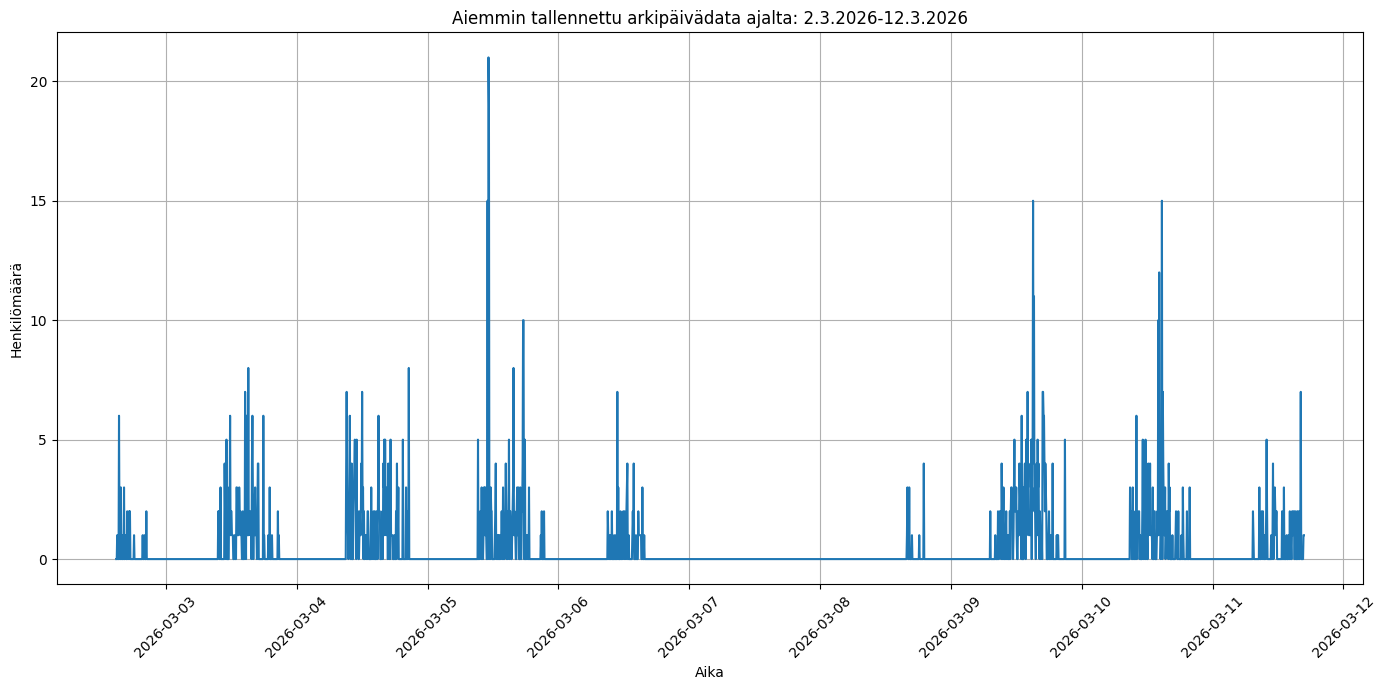

In [21]:
df['TimeStamp'] = pd.to_datetime(df['TimeStamp'], format='%d.%m.%Y klo %H.%M.%S')

df = df.sort_values(by='TimeStamp')

# Koko Robo Garagen datan henkilömäärän visualisointi
plt.figure(figsize=(14, 7))
sns.lineplot(x='TimeStamp', y='person count', data=df)
plt.title('Aiemmin tallennettu arkipäivädata ajalta: 2.3.2026-12.3.2026')
plt.xlabel('Aika')
plt.ylabel('Henkilömäärä')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Automaatio laboratorion Data

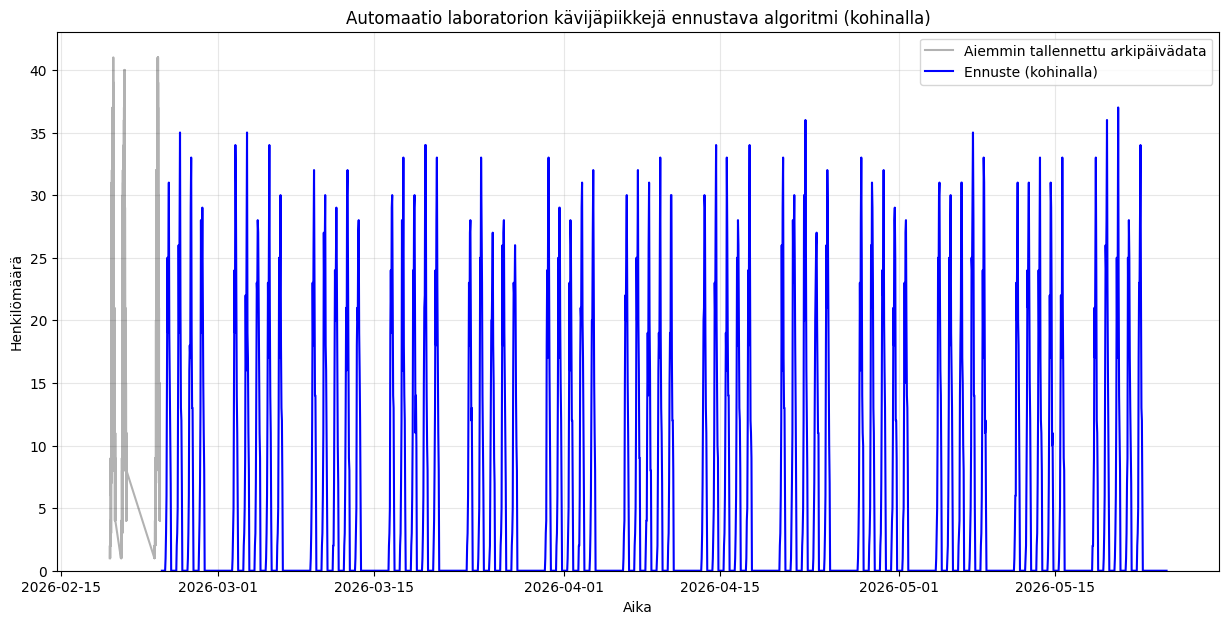

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ladataan simuloitu data
df_simulated = pd.read_json('/content/simulated.data.json')
payload_df_simulated = pd.json_normalize(df_simulated['payload'])

cols_to_drop = ['payload']
if 'TimeStamp' in df_simulated.columns:
    cols_to_drop.append('TimeStamp')

df_simulated_base = df_simulated.drop(columns=cols_to_drop)

payload_df_simulated = payload_df_simulated.rename(columns={'Time': 'TimeStamp', 'pCount': 'person count'})

df_simulated = pd.concat([df_simulated_base, payload_df_simulated], axis=1)
df_simulated['TimeStamp'] = pd.to_datetime(df_simulated['TimeStamp'], format='%d %b %Y %H:%M:%S', errors='coerce')
df_simulated = df_simulated.dropna(subset=['TimeStamp'])
df_simulated = df_simulated.sort_values(by='TimeStamp')

start_train_simulated = pd.to_datetime('2026-02-17 00:00:00')
end_train_simulated = pd.to_datetime('2026-02-23 23:59:59')
train_data_full_simulated = df_simulated[(df_simulated['TimeStamp'] >= start_train_simulated) & (df_simulated['TimeStamp'] <= end_train_simulated)].copy()

train_data_full_simulated['hour'] = train_data_full_simulated['TimeStamp'].dt.hour
train_data_full_simulated['day_of_week'] = train_data_full_simulated['TimeStamp'].dt.dayofweek


school_hours_data_simulated = train_data_full_simulated[
    (train_data_full_simulated['day_of_week'] <= 4) &
    (train_data_full_simulated['hour'] >= 8) &
    (train_data_full_simulated['hour'] <= 19)
]


hourly_profile_simulated = school_hours_data_simulated.groupby('hour')['person count'].mean().reindex(range(8, 20), fill_value=0)
hourly_std_simulated = school_hours_data_simulated.groupby('hour')['person count'].std().reindex(range(8, 20), fill_value=0)
hourly_std_simulated = hourly_std_simulated.fillna(0)


# Luodaan ennuste 3 kuukaudelle
future_dates_simulated = pd.date_range(start='2026-02-24', periods=90*24, freq='h')
forecast_df_simulated = pd.DataFrame({'TimeStamp': future_dates_simulated})
forecast_df_simulated['hour'] = forecast_df_simulated['TimeStamp'].dt.hour
forecast_df_simulated['day_of_week'] = forecast_df_simulated['TimeStamp'].dt.dayofweek

def get_historical_prediction_simulated(row):
    if row['day_of_week'] <= 4 and 8 <= row['hour'] <= 19:
        return hourly_profile_simulated.get(row['hour'], 0)
    return 0

forecast_df_simulated['predicted_count_base'] = forecast_df_simulated.apply(get_historical_prediction_simulated, axis=1)

# Kohinan lisäys
def add_realistic_noise_simulated(row):
    if row['day_of_week'] <= 4 and 8 <= row['hour'] <= 19:
        std_dev = hourly_std_simulated.get(row['hour'], 0)
        noise = np.random.normal(0, std_dev * 0.5)
        return max(0, round(row['predicted_count_base'] + noise))
    return round(row['predicted_count_base'])

forecast_df_simulated['predicted_count_realistic'] = forecast_df_simulated.apply(add_realistic_noise_simulated, axis=1)


# Visualisointi
plt.figure(figsize=(15, 7))
sns.lineplot(x='TimeStamp', y='person count', data=school_hours_data_simulated, label='Aiemmin tallennettu arkipäivädata', color='black', alpha=0.3)
sns.lineplot(x='TimeStamp', y='predicted_count_realistic', data=forecast_df_simulated, label='Ennuste (kohinalla)', color='blue')

plt.title('Automaatio laboratorion kävijäpiikkejä ennustava algoritmi (kohinalla)')
plt.xlabel('Aika')
plt.ylabel('Henkilömäärä')
plt.ylim(bottom=0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()